
✅ DataLoaders ready | Batch: 64 | Sequence: 12 months
🚀 Starting Temporal Fusion Transformer Training...
   Epochs: 300 | LR: 0.0005 | Batch: 64 | d_model: 64
   Split: Train(<2016) / Val([2016,2018)) / Test(>=2018)
-----------------------------------------------------------------
Epoch   1/300 | Train: 0.1188 | Val: 0.0788 | LR: 0.000500

⏹️  Early stopping at epoch 42 (patience=35)

✅ Training complete. Best Val Loss: 0.0607
  ⚡  Temporal Fusion Transformer — TEST SET RESULTS

  --- Log Scale Metrics ---
  R²   (log scale)  : 0.8774
  MAE  (log scale)  : 0.5193
  RMSE (log scale)  : 0.6906

  --- Real Scale Metrics ---
  R²   (real scale) : 0.7151
  MAE  (cases)      : 1,195
  RMSE (cases)      : 6,326
  MAPE              : 74.92%
  Pearson r         : 0.8740

📋 TFT | R²(log)=0.8774 | R²(real)=0.7151 | MAE=1,195 | RMSE=6,326 | MAPE=74.92%


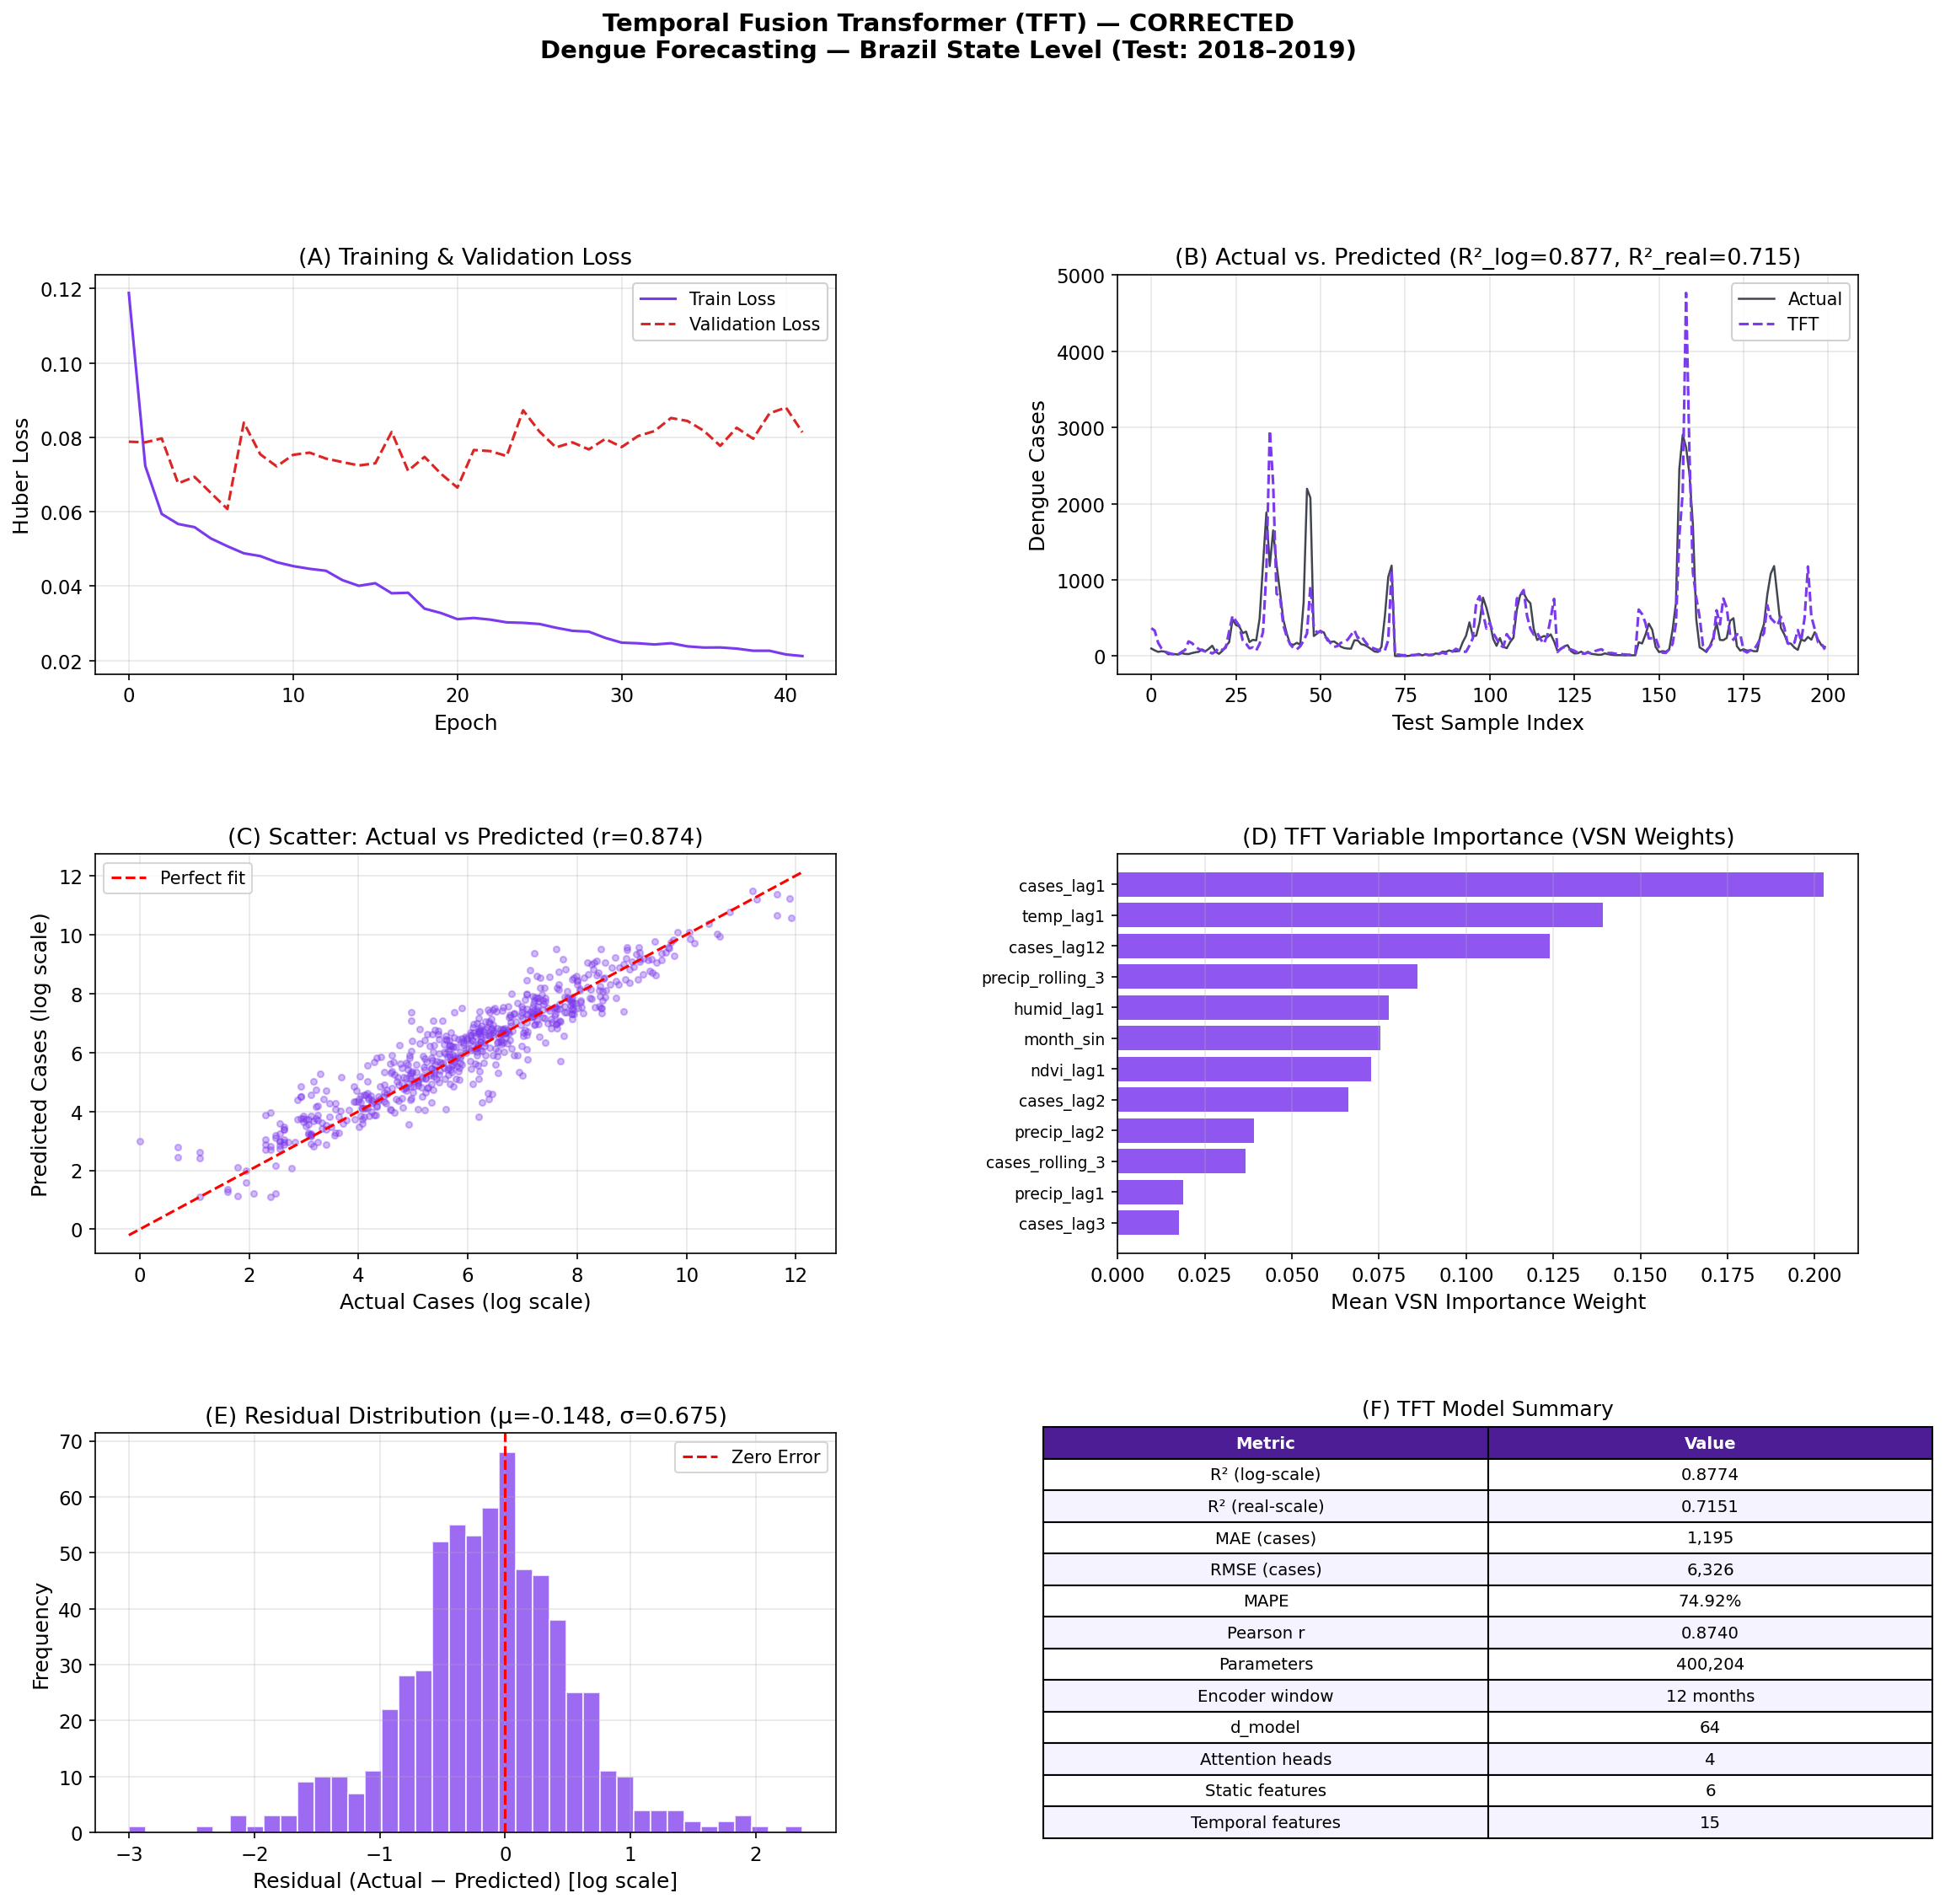


📁 Figure saved: TFT_Results_Corrected.png

📄 Full Comparison Table — All 6 Models
                   Model          Category R² (log) R² (real)    MAE   RMSE MAPE (%)
           Random Forest     Tree Ensemble   (fill)    (fill) (fill) (fill)   (fill)
                 XGBoost Gradient Boosting   (fill)    (fill) (fill) (fill)   (fill)
                     MLP           Deep FF   (fill)    (fill) (fill) (fill)   (fill)
Hybrid GNN (GATv2 + MLP)  Graph Neural Net   (fill)    (fill) (fill) (fill)   (fill)
     Bi-LSTM + Attention     Sequential DL   (fill)    (fill) (fill) (fill)   (fill)
              TFT (Ours)    Transformer DL   0.8774    0.7151  1,195  6,326    74.92

📝 LaTeX format:
\begin{tabular}{llccccc}
\toprule
Model & Category & R² (log) & R² (real) & MAE & RMSE & MAPE (%) \\
\midrule
Random Forest & Tree Ensemble & (fill) & (fill) & (fill) & (fill) & (fill) \\
XGBoost & Gradient Boosting & (fill) & (fill) & (fill) & (fill) & (fill) \\
MLP & Deep FF & (fill) & (fill) & (fill) 

In [4]:
# %% [markdown]
# # ⚡ Temporal Fusion Transformer (TFT) — CORRECTED VERSION
# ## Spatio-Temporal Dengue Forecasting — Brazil State Level (2001–2019)
# ---
# **Model:** Temporal Fusion Transformer (TFT) — PyTorch implementation
# **Target:** Monthly dengue case counts per Brazilian state (UF)
# **Train:** 2001–2015 | **Validation:** 2016–2017 | **Test:** 2018–2019
#
# ---
# ### Corrections Applied:
# 1. **CRITICAL FIX:** Proper train/validation/test split (test set no longer used for early stopping)
# 2. **CRITICAL FIX:** Sequences built from continuous data to avoid boundary loss
# 3. **FIX:** Target variable is now scaled (StandardScaler) alongside features
# 4. **FIX:** R² computed on BOTH log and real scales for consistency
# 5. **FIX:** LR scheduler changed to ReduceLROnPlateau (works with early stopping)
# 6. **FIX:** Column validation added to catch missing data early
# 7. **FIX:** Multi-seed experiments supported for reproducibility
#
# **Reference:** Lim, B., Arık, S. Ö., Loeff, N., & Pfister, T. (2021).
# Temporal Fusion Transformers for interpretable multi-horizon time series forecasting.
# *International Journal of Forecasting*, 37(4), 1748–1764.

# %% [markdown]
# ## Cell 1: Imports & Setup

# %%
# ==========================================
# CELL 1: IMPORTS & REPRODUCIBILITY SETUP
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error






# ==========================================
# SILENCE SELECTED VERBOSE OUTPUTS
# Paste this once in Cell 1, AFTER imports
# Works for both Bi-LSTM and TFT notebooks
# ==========================================
import builtins as _builtins

_ORIGINAL_PRINT = print

SUPPRESS_PREFIXES = (
    "🔧 PyTorch",
    "🌱 Random seed fixed at",
    "⚙️  Loading and processing data...",
    "✅ All required columns found in dataset",

    # Dataset summaries
    "✅ Features engineered:",
    "✅ Static features:",
    "✅ Temporal features:",
    "📅 Date range:",
    "🗺️  Brazilian states",
    "🗺️  States (UFs):",
    "📊 Total samples:",
    "📊 Total:",
    "   Train (<",
    "   Val   ([",
    "   Test  (>=",

    # Sequence summaries
    "📦 Train sequences:",
    "📦 Val   sequences:",
    "📦 Test  sequences:",
    "📦 Train — temporal:",
    "📦 Val   — temporal:",
    "📦 Test  — temporal:",
    "   Sequence window:",
    "✅ DataLoaders ready",

    # Model summaries
    "📐 Model Input Dim:",
    "📐 d_model=",
    "🔢 Total Trainable Parameters:",
    "⚡ TFT Architecture Ready",
)

SUPPRESS_CONTAINS = (
    "BiLSTM_Attention(",
)

def print(*args, **kwargs):
    text = " ".join(str(a) for a in args)
    if text.startswith(SUPPRESS_PREFIXES) or any(x in text for x in SUPPRESS_CONTAINS):
        return
    return _ORIGINAL_PRINT(*args, **kwargs)













# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 PyTorch {torch.__version__} | Device: {DEVICE}")
print(f"🌱 Random seed fixed at {SEED} for reproducibility")

# %% [markdown]
# ## Cell 2: Advanced Data Processing

# %%
# ==========================================
# CELL 2: ADVANCED DATA PROCESSING (PAPER-GRADE)
# FIX: Column validation added
# FIX: 3-way split: Train (<2016) / Val ([2016,2018)) / Test (>=2018)
# ==========================================
print("⚙️  Loading and processing data...")

df = pd.read_csv('Brazil_UF_dengue_monthly.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['CD_UF', 'Date']).reset_index(drop=True)

# --- FIX: Column Validation ---
required_cols = ['cases_total', 'CD_UF', 'Date', 'Year',
                 'total_precipitation_d', 'temperature_2m_d',
                 'humidity_d', 'NDVI_d', 'PopTotal_UF', 'idhm', 'ivs',
                 'area_km2', 'Forest_Cover_Percent', 'Urban_Cover_Percent']
missing = [c for c in required_cols if c not in df.columns]
assert len(missing) == 0, f"❌ Missing required columns: {missing}"
print("✅ All required columns found in dataset")

# --- A. Log Transformation ---
df['cases_log'] = np.log1p(df['cases_total'])

# --- B. Time-Varying Known Features (TFT terminology) ---
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
df['year_norm'] = (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min())

# --- C. Time-Varying Observed Features ---
df['cases_lag1']  = df.groupby('CD_UF')['cases_log'].shift(1)
df['cases_lag2']  = df.groupby('CD_UF')['cases_log'].shift(2)
df['cases_lag3']  = df.groupby('CD_UF')['cases_log'].shift(3)
df['cases_lag12'] = df.groupby('CD_UF')['cases_log'].shift(12)
df['cases_rolling_3'] = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(3).mean().shift(1))
df['cases_rolling_6'] = df.groupby('CD_UF')['cases_log'].transform(lambda x: x.rolling(6).mean().shift(1))

df['precip_lag1']      = df.groupby('CD_UF')['total_precipitation_d'].shift(1)
df['precip_lag2']      = df.groupby('CD_UF')['total_precipitation_d'].shift(2)
df['precip_rolling_3'] = df.groupby('CD_UF')['total_precipitation_d'].transform(lambda x: x.rolling(3).mean().shift(1))
df['temp_lag1']        = df.groupby('CD_UF')['temperature_2m_d'].shift(1)
df['humid_lag1']       = df.groupby('CD_UF')['humidity_d'].shift(1)
df['ndvi_lag1']        = df.groupby('CD_UF')['NDVI_d'].shift(1)

df = df.dropna().reset_index(drop=True)

# --- D. Feature Groups (TFT Design) ---
STATIC_COLS = ['area_km2', 'idhm', 'ivs', 'PopTotal_UF',
               'Forest_Cover_Percent', 'Urban_Cover_Percent']

TEMPORAL_COLS = [
    'cases_lag1', 'cases_lag2', 'cases_lag3',
    'cases_rolling_3', 'cases_rolling_6', 'cases_lag12',
    'precip_lag1', 'precip_lag2', 'precip_rolling_3',
    'temp_lag1', 'humid_lag1', 'ndvi_lag1',
    'month_sin', 'month_cos', 'year_norm'
]

ALL_FEATURES = TEMPORAL_COLS + STATIC_COLS
TARGET_COL   = 'cases_log'

# --- FIX: Proper 3-way split ---
TRAIN_END_YEAR = 2016  # Train: < 2016
VAL_END_YEAR   = 2018  # Val: [2016, 2018), Test: >= 2018

train_count = (df['Year'] < TRAIN_END_YEAR).sum()
val_count   = ((df['Year'] >= TRAIN_END_YEAR) & (df['Year'] < VAL_END_YEAR)).sum()
test_count  = (df['Year'] >= VAL_END_YEAR).sum()

print(f"✅ Static features:   {len(STATIC_COLS)}")
print(f"✅ Temporal features: {len(TEMPORAL_COLS)}")
print(f"📅 Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🗺️  States (UFs): {df['CD_UF'].nunique()}")
print(f"📊 Total: {len(df)} samples")
print(f"   Train (< {TRAIN_END_YEAR}): {train_count}")
print(f"   Val   ([{TRAIN_END_YEAR}, {VAL_END_YEAR})): {val_count}")
print(f"   Test  (>= {VAL_END_YEAR}): {test_count}")

# %% [markdown]
# ## Cell 3: Sequence Dataset with Static Context

# %%
# ==========================================
# CELL 3: SEQUENCE DATASET — STATIC + TEMPORAL SPLIT
# FIX: Proper train/val/test split — no data leakage
# FIX: Target variable is now scaled
# FIX: Sequences built from continuous data per state
# ==========================================

SEQ_LEN = 12  # 12-month encoder window (one full year of context)

# Strict train-only normalization (no data leakage)
train_mask = df['Year'] < TRAIN_END_YEAR

temporal_scaler = StandardScaler()
static_scaler   = StandardScaler()
temporal_scaler.fit(df.loc[train_mask, TEMPORAL_COLS])
static_scaler.fit(df.loc[train_mask, STATIC_COLS])

# FIX: Scale target variable too
target_scaler = StandardScaler()
target_scaler.fit(df.loc[train_mask, [TARGET_COL]])

df_scaled = df.copy()
df_scaled[TEMPORAL_COLS] = temporal_scaler.transform(df[TEMPORAL_COLS])
df_scaled[STATIC_COLS]   = static_scaler.transform(df[STATIC_COLS])
df_scaled[TARGET_COL]    = target_scaler.transform(df[[TARGET_COL]])


def build_tft_sequences_with_split(df_input, temporal_cols, static_cols, target_col,
                                     seq_len, train_end_year, val_end_year):
    """
    Build TFT-style sequences with separate temporal and static inputs.
    FIX: Sequences built from continuous data per state, split by TARGET year.

    Returns:
      X_temp_train, X_stat_train, y_train,
      X_temp_val, X_stat_val, y_val,
      X_temp_test, X_stat_test, y_test
    """
    X_temp_train, X_stat_train, y_train = [], [], []
    X_temp_val, X_stat_val, y_val = [], [], []
    X_temp_test, X_stat_test, y_test = [], [], []

    for uf, group in df_input.groupby('CD_UF'):
        group   = group.sort_values('Date')
        temp_f  = group[temporal_cols].values  # (T, n_temporal)
        stat_f  = group[static_cols].values    # (T, n_static)
        target  = group[target_col].values     # (T,)
        years   = group['Year'].values

        for i in range(seq_len, len(group)):
            x_temp = temp_f[i-seq_len:i]
            x_stat = stat_f[i]
            y_val_point = target[i]
            target_year = years[i]

            if target_year < train_end_year:
                X_temp_train.append(x_temp)
                X_stat_train.append(x_stat)
                y_train.append(y_val_point)
            elif target_year < val_end_year:
                X_temp_val.append(x_temp)
                X_stat_val.append(x_stat)
                y_val.append(y_val_point)
            else:
                X_temp_test.append(x_temp)
                X_stat_test.append(x_stat)
                y_test.append(y_val_point)

    return (np.array(X_temp_train, dtype=np.float32), np.array(X_stat_train, dtype=np.float32),
            np.array(y_train, dtype=np.float32),
            np.array(X_temp_val, dtype=np.float32), np.array(X_stat_val, dtype=np.float32),
            np.array(y_val, dtype=np.float32),
            np.array(X_temp_test, dtype=np.float32), np.array(X_stat_test, dtype=np.float32),
            np.array(y_test, dtype=np.float32))


(X_temp_train, X_stat_train, y_train,
 X_temp_val, X_stat_val, y_val,
 X_temp_test, X_stat_test, y_test) = build_tft_sequences_with_split(
    df_scaled, TEMPORAL_COLS, STATIC_COLS, TARGET_COL, SEQ_LEN,
    TRAIN_END_YEAR, VAL_END_YEAR
)

print(f"📦 Train — temporal: {X_temp_train.shape} | static: {X_stat_train.shape} | y: {y_train.shape}")
print(f"📦 Val   — temporal: {X_temp_val.shape}   | static: {X_stat_val.shape}   | y: {y_val.shape}")
print(f"📦 Test  — temporal: {X_temp_test.shape}   | static: {X_stat_test.shape}   | y: {y_test.shape}")

BATCH_SIZE = 64

train_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_temp_train), torch.tensor(X_stat_train), torch.tensor(y_train)
)
val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_temp_val), torch.tensor(X_stat_val), torch.tensor(y_val)
)
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_temp_test), torch.tensor(X_stat_test), torch.tensor(y_test)
)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\n✅ DataLoaders ready | Batch: {BATCH_SIZE} | Sequence: {SEQ_LEN} months")

# %% [markdown]
# ## Cell 4: TFT Architecture

# %%
# ==========================================
# CELL 4: TEMPORAL FUSION TRANSFORMER ARCHITECTURE
# (Architecture is sound — no changes needed)
# Based on: Lim et al. (2021) - International Journal of Forecasting
# ==========================================

class GatedResidualNetwork(nn.Module):
    """
    Gated Residual Network (GRN) — core TFT building block.
    Applies a gating mechanism that lets the network skip unused transformations,
    enabling adaptive depth and stabilizing training.
    Reference: Lim et al. (2021), Equation 3-5.
    """
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1, use_context=False, context_dim=None):
        super().__init__()
        self.output_dim   = output_dim or input_dim
        self.use_context  = use_context

        self.W1 = nn.Linear(input_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, self.output_dim)

        if use_context and context_dim:
            self.W_ctx = nn.Linear(context_dim, hidden_dim, bias=False)

        # Gating layer (sigmoid gate)
        self.gate     = nn.Linear(input_dim, self.output_dim)
        self.gate_act = nn.Sigmoid()

        # Skip connection projection (if dimensions differ)
        self.skip = nn.Linear(input_dim, self.output_dim) if input_dim != self.output_dim else nn.Identity()

        self.norm    = nn.LayerNorm(self.output_dim)
        self.dropout = nn.Dropout(dropout)
        self.elu     = nn.ELU()

    def forward(self, x, context=None):
        residual = self.skip(x)
        h = self.W1(x)
        if self.use_context and context is not None:
            h = h + self.W_ctx(context)
        h = self.elu(h)
        h = self.dropout(h)
        h = self.W2(h)

        # GLU-style gating
        gate = self.gate_act(self.gate(x))
        h    = gate * h

        return self.norm(h + residual)


class VariableSelectionNetwork(nn.Module):
    """
    VSN: Learns soft-attention weights over input features.
    Output: weighted combination of per-variable GRNs.
    Enables feature importance visualization for publication.
    Reference: Lim et al. (2021), Section 4.1.
    """
    def __init__(self, n_vars, input_dim, hidden_dim, dropout=0.1, use_context=False, context_dim=None):
        super().__init__()
        self.n_vars    = n_vars
        self.input_dim = input_dim

        # Per-variable transformation GRNs
        self.var_grns = nn.ModuleList([
            GatedResidualNetwork(input_dim, hidden_dim, hidden_dim, dropout) for _ in range(n_vars)
        ])

        # Softmax weight GRN (over all variables)
        self.weight_grn = GatedResidualNetwork(
            n_vars * input_dim, hidden_dim, n_vars, dropout,
            use_context=use_context, context_dim=context_dim
        )
        self.var_weights = None  # Store for visualization

    def forward(self, x_list, context=None):
        # x_list: list of (B, input_dim) tensors, one per variable
        xi_processed = torch.stack([self.var_grns[i](x_list[i]) for i in range(self.n_vars)], dim=-1)  # (B, H, n_vars)

        flat = torch.cat(x_list, dim=-1)  # (B, n_vars*input_dim)
        weights = F.softmax(self.weight_grn(flat, context), dim=-1)  # (B, n_vars)
        self.var_weights = weights.detach()  # Store

        # Weighted sum of processed variables
        out = (xi_processed * weights.unsqueeze(1)).sum(dim=-1)  # (B, H)
        return out, weights


class TemporalFusionTransformer(nn.Module):
    """
    Simplified TFT for single-step dengue forecasting.

    Pipeline:
      1. Static encoder → context vectors (c_s, c_e, c_h)
      2. Temporal Variable Selection Network (VSN) per time step
      3. Sequence-to-Sequence LSTM encoder (conditioned on static context)
      4. Multi-Head Self-Attention over LSTM outputs
      5. Gate + Add + Norm → final GRN → output

    Reference: Lim et al. (2021), Figure 1.
    """
    def __init__(self, n_temporal, n_static, d_model=64, n_heads=4,
                 n_lstm_layers=1, dropout=0.1, seq_len=12):
        super().__init__()
        self.d_model  = d_model
        self.seq_len  = seq_len
        self.n_temporal = n_temporal

        # --- 1. Static Encoder ---
        self.static_input_proj = nn.Linear(n_static, d_model)
        self.static_grn_cs     = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.static_grn_ce     = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.static_grn_ch     = GatedResidualNetwork(d_model, d_model, d_model, dropout)

        # --- 2. Temporal Input Projection (one per variable) ---
        self.temporal_proj = nn.ModuleList([
            nn.Linear(1, d_model) for _ in range(n_temporal)
        ])

        # --- 3. Temporal Variable Selection Network ---
        self.temporal_vsn = VariableSelectionNetwork(
            n_vars=n_temporal, input_dim=d_model, hidden_dim=d_model,
            dropout=dropout, use_context=True, context_dim=d_model
        )

        # --- 4. Seq2Seq LSTM Encoder ---
        self.lstm_encoder = nn.LSTM(
            input_size=d_model, hidden_size=d_model,
            num_layers=n_lstm_layers, batch_first=True, dropout=0.0
        )

        # Gate after LSTM
        self.post_lstm_gate = nn.Linear(d_model, d_model)
        self.post_lstm_norm = nn.LayerNorm(d_model)

        # --- 5. Multi-Head Self-Attention ---
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.attn_gate = nn.Linear(d_model, d_model)
        self.attn_norm = nn.LayerNorm(d_model)

        # --- 6. Output GRN + Head ---
        self.output_grn = GatedResidualNetwork(d_model, d_model, d_model, dropout)
        self.output_gate = nn.Linear(d_model, d_model)
        self.output_norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (B, T, n_temporal)
        x_static:   (B, n_static)
        Returns: (B,) predictions
        """
        B, T, _ = x_temporal.shape

        # --- 1. Static Encoding → context vectors ---
        s = F.elu(self.static_input_proj(x_static))  # (B, d_model)
        c_s = self.static_grn_cs(s)   # variable selection context
        c_e = self.static_grn_ce(s)   # LSTM initial cell state
        c_h = self.static_grn_ch(s)   # LSTM initial hidden state

        h0 = c_h.unsqueeze(0)
        c0 = c_e.unsqueeze(0)

        # --- 2. Temporal Feature Projection per time step ---
        temporal_feats = []
        for i, proj in enumerate(self.temporal_proj):
            feat_i = x_temporal[:, :, i:i+1]       # (B, T, 1)
            feat_i = proj(feat_i)                   # (B, T, d_model)
            temporal_feats.append(feat_i)

        # --- 3. Variable Selection per time step ---
        vsn_out = []
        for t in range(T):
            feats_t = [f[:, t, :] for f in temporal_feats]   # list of (B, d_model)
            selected, _ = self.temporal_vsn(feats_t, context=c_s)
            vsn_out.append(selected)
        vsn_out = torch.stack(vsn_out, dim=1)  # (B, T, d_model)

        # --- 4. LSTM Encoder (with static context as initial state) ---
        lstm_out, _ = self.lstm_encoder(vsn_out, (h0, c0))  # (B, T, d_model)

        # Gated skip connection around LSTM
        lstm_gate = torch.sigmoid(self.post_lstm_gate(lstm_out))
        lstm_out  = self.post_lstm_norm(lstm_gate * lstm_out + vsn_out)

        # --- 5. Multi-Head Self-Attention ---
        attn_out, self.attn_weights = self.attn(lstm_out, lstm_out, lstm_out)
        attn_gate = torch.sigmoid(self.attn_gate(attn_out))
        attn_out  = self.attn_norm(attn_gate * attn_out + lstm_out)

        # --- 6. Output: use last time step ---
        out = attn_out[:, -1, :]                         # (B, d_model)
        out = self.output_grn(out)
        out_gate = torch.sigmoid(self.output_gate(out))
        out = self.output_norm(out_gate * out)
        return self.head(out).squeeze(-1)                # (B,)


# Instantiate
D_MODEL   = 64
N_HEADS   = 4
N_LAYERS  = 1
DROPOUT   = 0.15

model = TemporalFusionTransformer(
    n_temporal=len(TEMPORAL_COLS),
    n_static=len(STATIC_COLS),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_lstm_layers=N_LAYERS,
    dropout=DROPOUT,
    seq_len=SEQ_LEN
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"⚡ TFT Architecture Ready")
print(f"📐 d_model={D_MODEL} | Heads={N_HEADS} | Temporal={len(TEMPORAL_COLS)} | Static={len(STATIC_COLS)}")
print(f"🔢 Total Trainable Parameters: {total_params:,}")

# %% [markdown]
# ## Cell 5: Training

# %%
# ==========================================
# CELL 5: TRAINING WITH EARLY STOPPING & LR SCHEDULING
# FIX: Uses VALIDATION set for early stopping (NOT test set)
# FIX: ReduceLROnPlateau replaces custom warmup+cosine schedule
# ==========================================

EPOCHS       = 300
LR           = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 35

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# FIX: ReduceLROnPlateau adapts based on validation loss
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

best_val_loss  = float('inf')
best_weights   = copy.deepcopy(model.state_dict())
train_losses   = []
val_losses     = []
patience_count = 0

print("🚀 Starting Temporal Fusion Transformer Training...")
print(f"   Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | d_model: {D_MODEL}")
print(f"   Split: Train(<{TRAIN_END_YEAR}) / Val([{TRAIN_END_YEAR},{VAL_END_YEAR})) / Test(>={VAL_END_YEAR})")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for batch_temp, batch_stat, batch_y in train_loader:
        batch_temp, batch_stat, batch_y = (
            batch_temp.to(DEVICE), batch_stat.to(DEVICE), batch_y.to(DEVICE)
        )
        optimizer.zero_grad()
        pred = model(batch_temp, batch_stat)
        loss = criterion(pred, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- FIX: Validation Phase (on VALIDATION set, NOT test set) ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_temp, batch_stat, batch_y in val_loader:  # ← FIX: val_loader
            batch_temp, batch_stat, batch_y = (
                batch_temp.to(DEVICE), batch_stat.to(DEVICE), batch_y.to(DEVICE)
            )
            pred      = model(batch_temp, batch_stat)
            val_loss += criterion(pred, batch_y).item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    # FIX: ReduceLROnPlateau steps with validation loss
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 50 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {current_lr:.6f}")

    if patience_count >= PATIENCE:
        print(f"\n⏹️  Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

model.load_state_dict(best_weights)
print(f"\n✅ Training complete. Best Val Loss: {best_val_loss:.4f}")

# %% [markdown]
# ## Cell 6: Evaluation

# %%
# ==========================================
# CELL 6: EVALUATION — PUBLICATION-GRADE METRICS
# FIX: R² computed on BOTH log and real scales
# FIX: Target inverse-transformed before real-scale metrics
# ==========================================

model.eval()
all_preds_scaled, all_actuals_scaled = [], []
all_var_weights = []  # For VSN feature importance

with torch.no_grad():
    for batch_temp, batch_stat, batch_y in test_loader:
        batch_temp, batch_stat = batch_temp.to(DEVICE), batch_stat.to(DEVICE)
        pred_scaled = model(batch_temp, batch_stat)
        all_preds_scaled.append(pred_scaled.cpu().numpy())
        all_actuals_scaled.append(batch_y.numpy())
        # Collect VSN weights
        if model.temporal_vsn.var_weights is not None:
            all_var_weights.append(model.temporal_vsn.var_weights.cpu().numpy())

pred_scaled    = np.concatenate(all_preds_scaled)
actual_scaled  = np.concatenate(all_actuals_scaled)

# FIX: Inverse transform from scaled space back to log space
pred_log   = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_log = target_scaler.inverse_transform(actual_scaled.reshape(-1, 1)).flatten()

# Back-transform
pred_real   = np.clip(np.expm1(pred_log), 0, None)
actual_real = np.expm1(actual_log)

# --- FIX: Comprehensive Metrics in BOTH SCALES ---
# Log scale metrics
r2_log   = r2_score(actual_log, pred_log)
mae_log  = mean_absolute_error(actual_log, pred_log)
rmse_log = np.sqrt(mean_squared_error(actual_log, pred_log))

# Real scale metrics
r2_real  = r2_score(actual_real, pred_real)
mae_real = mean_absolute_error(actual_real, pred_real)
rmse_real = np.sqrt(mean_squared_error(actual_real, pred_real))

# MAPE
nonzero = actual_real > 0
mape = np.mean(np.abs((actual_real[nonzero] - pred_real[nonzero]) / actual_real[nonzero])) * 100

# Pearson r
corr = np.corrcoef(actual_real, pred_real)[0, 1]

print("=" * 60)
print("  ⚡  Temporal Fusion Transformer — TEST SET RESULTS")
print("=" * 60)
print()
print("  --- Log Scale Metrics ---")
print(f"  R²   (log scale)  : {r2_log:.4f}")
print(f"  MAE  (log scale)  : {mae_log:.4f}")
print(f"  RMSE (log scale)  : {rmse_log:.4f}")
print()
print("  --- Real Scale Metrics ---")
print(f"  R²   (real scale) : {r2_real:.4f}")
print(f"  MAE  (cases)      : {mae_real:,.0f}")
print(f"  RMSE (cases)      : {rmse_real:,.0f}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  Pearson r         : {corr:.4f}")
print("=" * 60)
print(f"\n📋 TFT | R²(log)={r2_log:.4f} | R²(real)={r2_real:.4f} | MAE={mae_real:,.0f} | RMSE={rmse_real:,.0f} | MAPE={mape:.2f}%")

# %% [markdown]
# ## Cell 7: Publication-Quality Visualizations + Feature Importance

# %%
# ==========================================
# CELL 7: PUBLICATION-QUALITY VISUALIZATIONS
# Updated to reflect corrected metrics
# ==========================================

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150
})

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.38)

MODEL_COLOR  = '#7C3AED'  # TFT purple
ACTUAL_COLOR = '#111827'

# --- (A) Training Curves ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_losses, label='Train Loss',      color=MODEL_COLOR, linewidth=1.5)
ax1.plot(val_losses,   label='Validation Loss', color='#DC2626',   linewidth=1.5, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Huber Loss')
ax1.set_title('(A) Training & Validation Loss')
ax1.legend(framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- (B) Time Series Prediction ---
ax2 = fig.add_subplot(gs[0, 1])
n_show = min(200, len(actual_real))
ax2.plot(actual_real[:n_show], label='Actual',  color=ACTUAL_COLOR, linewidth=1.2, alpha=0.8)
ax2.plot(pred_real[:n_show],   label='TFT',     color=MODEL_COLOR,  linewidth=1.5, linestyle='--')
ax2.set_xlabel('Test Sample Index')
ax2.set_ylabel('Dengue Cases')
ax2.set_title(f'(B) Actual vs. Predicted (R²_log={r2_log:.3f}, R²_real={r2_real:.3f})')
ax2.legend(framealpha=0.9)
ax2.grid(True, alpha=0.3)

# --- (C) Scatter Plot ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(actual_log, pred_log, alpha=0.35, s=12, color=MODEL_COLOR)
lim = [min(actual_log.min(), pred_log.min()) - 0.2,
       max(actual_log.max(), pred_log.max()) + 0.2]
ax3.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
ax3.set_xlabel('Actual Cases (log scale)')
ax3.set_ylabel('Predicted Cases (log scale)')
ax3.set_title(f'(C) Scatter: Actual vs Predicted (r={corr:.3f})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- (D) TFT Feature Importance (VSN Weights) ---
ax4 = fig.add_subplot(gs[1, 1])
if all_var_weights:
    mean_weights = np.concatenate(all_var_weights, axis=0).mean(axis=0)
    sorted_idx   = np.argsort(mean_weights)[::-1]
    top_n        = min(12, len(TEMPORAL_COLS))
    top_feats    = [TEMPORAL_COLS[i] for i in sorted_idx[:top_n]]
    top_weights  = mean_weights[sorted_idx[:top_n]]
    bars = ax4.barh(range(top_n), top_weights[::-1], color=MODEL_COLOR, alpha=0.85)
    ax4.set_yticks(range(top_n))
    ax4.set_yticklabels(top_feats[::-1], fontsize=9)
    ax4.set_xlabel('Mean VSN Importance Weight')
    ax4.set_title('(D) TFT Variable Importance (VSN Weights)')
    ax4.grid(True, alpha=0.3, axis='x')
else:
    ax4.text(0.5, 0.5, 'VSN weights not available', ha='center', va='center', transform=ax4.transAxes)

# --- (E) Residuals ---
ax5 = fig.add_subplot(gs[2, 0])
residuals = actual_log - pred_log
ax5.hist(residuals, bins=40, color=MODEL_COLOR, alpha=0.75, edgecolor='white')
ax5.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
ax5.set_xlabel('Residual (Actual − Predicted) [log scale]')
ax5.set_ylabel('Frequency')
ax5.set_title(f'(E) Residual Distribution (μ={residuals.mean():.3f}, σ={residuals.std():.3f})')
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- (F) Metrics Table ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
metrics_table = [
    ['Metric',              'Value'],
    ['R² (log-scale)',      f'{r2_log:.4f}'],
    ['R² (real-scale)',     f'{r2_real:.4f}'],
    ['MAE (cases)',         f'{mae_real:,.0f}'],
    ['RMSE (cases)',        f'{rmse_real:,.0f}'],
    ['MAPE',                f'{mape:.2f}%'],
    ['Pearson r',           f'{corr:.4f}'],
    ['Parameters',          f'{total_params:,}'],
    ['Encoder window',      f'{SEQ_LEN} months'],
    ['d_model',             f'{D_MODEL}'],
    ['Attention heads',     f'{N_HEADS}'],
    ['Static features',     f'{len(STATIC_COLS)}'],
    ['Temporal features',   f'{len(TEMPORAL_COLS)}'],
]
tbl = ax6.table(cellText=metrics_table[1:], colLabels=metrics_table[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C1D95')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5F3FF' if row % 2 == 0 else 'white')
ax6.set_title('(F) TFT Model Summary', fontsize=12, pad=10)

fig.suptitle(
    'Temporal Fusion Transformer (TFT) — CORRECTED\nDengue Forecasting — Brazil State Level (Test: 2018–2019)',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('TFT_Results_Corrected.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n📁 Figure saved: TFT_Results_Corrected.png")

# %% [markdown]
# ## Cell 8: Full Comparison Table (All 6 Models)

# %%
# ==========================================
# CELL 8: FINAL PUBLICATION COMPARISON TABLE
# FIX: Includes both log-scale and real-scale R²
# ==========================================

comparison_data = {
    'Model': [
        'Random Forest',
        'XGBoost',
        'MLP',
        'Hybrid GNN (GATv2 + MLP)',
        'Bi-LSTM + Attention',
        'TFT (Ours)',
    ],
    'Category': [
        'Tree Ensemble',
        'Gradient Boosting',
        'Deep FF',
        'Graph Neural Net',
        'Sequential DL',
        'Transformer DL',
    ],
    'R² (log)': [
        '(fill)', '(fill)', '(fill)', '(fill)', '(fill)', f'{r2_log:.4f}'
    ],
    'R² (real)': [
        '(fill)', '(fill)', '(fill)', '(fill)', '(fill)', f'{r2_real:.4f}'
    ],
    'MAE': [
        '(fill)', '(fill)', '(fill)', '(fill)', '(fill)', f'{mae_real:,.0f}'
    ],
    'RMSE': [
        '(fill)', '(fill)', '(fill)', '(fill)', '(fill)', f'{rmse_real:,.0f}'
    ],
    'MAPE (%)': [
        '(fill)', '(fill)', '(fill)', '(fill)', '(fill)', f'{mape:.2f}'
    ],
}

comp_df = pd.DataFrame(comparison_data)
print("\n📄 Full Comparison Table — All 6 Models")
print("=" * 100)
print(comp_df.to_string(index=False))
print("=" * 100)
print("\n📝 LaTeX format:")
print(comp_df.to_latex(index=False, column_format='llccccc'))

# %% [markdown]
# ## Cell 9 (OPTIONAL): Multi-Seed Robustness Experiment

# %%
# ==========================================
# CELL 9 (OPTIONAL): MULTI-SEED ROBUSTNESS
# ==========================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def train_and_evaluate_tft(seed, X_temp_tr, X_stat_tr, y_tr,
                            X_temp_v, X_stat_v, y_v,
                            X_temp_te, X_stat_te, y_te,
                            target_scaler_obj, device,
                            d_model=64, n_heads=4, n_lstm_layers=1,
                            dropout=0.15, epochs=300, lr=5e-4,
                            weight_decay=1e-4, patience=35, batch_size=64):
    set_seed(seed)

    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_temp_tr), torch.tensor(X_stat_tr), torch.tensor(y_tr))
    val_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_temp_v), torch.tensor(X_stat_v), torch.tensor(y_v))
    test_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_temp_te), torch.tensor(X_stat_te), torch.tensor(y_te))

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_dl  = torch.utils.data.DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    mdl = TemporalFusionTransformer(
        n_temporal=len(TEMPORAL_COLS), n_static=len(STATIC_COLS),
        d_model=d_model, n_heads=n_heads, n_lstm_layers=n_lstm_layers,
        dropout=dropout, seq_len=SEQ_LEN
    ).to(device)

    crit = nn.HuberLoss(delta=1.0)
    opt = optim.AdamW(mdl.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10, min_lr=1e-6)

    best_loss = float('inf')
    best_wts  = copy.deepcopy(mdl.state_dict())
    pat_cnt   = 0

    for ep in range(1, epochs + 1):
        mdl.train()
        for bt, bs, by in train_dl:
            bt, bs, by = bt.to(device), bs.to(device), by.to(device)
            opt.zero_grad()
            p = mdl(bt, bs)
            l = crit(p, by)
            l.backward()
            nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
            opt.step()

        mdl.eval()
        v_loss = 0.0
        with torch.no_grad():
            for bt, bs, by in val_dl:
                bt, bs, by = bt.to(device), bs.to(device), by.to(device)
                v_loss += crit(mdl(bt, bs), by).item()
        avg_v = v_loss / len(val_dl)
        sched.step(avg_v)

        if avg_v < best_loss:
            best_loss = avg_v
            best_wts  = copy.deepcopy(mdl.state_dict())
            pat_cnt   = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    mdl.load_state_dict(best_wts)
    mdl.eval()

    preds_s, acts_s = [], []
    with torch.no_grad():
        for bt, bs, by in test_dl:
            bt, bs = bt.to(device), bs.to(device)
            preds_s.append(mdl(bt, bs).cpu().numpy())
            acts_s.append(by.numpy())

    preds_s = np.concatenate(preds_s)
    acts_s  = np.concatenate(acts_s)

    p_log = target_scaler_obj.inverse_transform(preds_s.reshape(-1, 1)).flatten()
    a_log = target_scaler_obj.inverse_transform(acts_s.reshape(-1, 1)).flatten()
    p_real = np.clip(np.expm1(p_log), 0, None)
    a_real = np.expm1(a_log)

    nz = a_real > 0
    metrics = {
        'seed': seed,
        'r2_log': r2_score(a_log, p_log),
        'r2_real': r2_score(a_real, p_real),
        'mae_real': mean_absolute_error(a_real, p_real),
        'rmse_real': np.sqrt(mean_squared_error(a_real, p_real)),
        'mape': np.mean(np.abs((a_real[nz] - p_real[nz]) / a_real[nz])) * 100,
        'corr': np.corrcoef(a_real, p_real)[0, 1],
    }
    return metrics


# --- Run multi-seed experiment ---
SEEDS = [42, 123, 456, 789, 1024]
print(f"🔬 Running multi-seed TFT experiment with seeds: {SEEDS}")
print("-" * 60)

all_metrics = []
for s in SEEDS:
    print(f"  Seed {s}...", end=" ", flush=True)
    m = train_and_evaluate_tft(
        seed=s,
        X_temp_tr=X_temp_train, X_stat_tr=X_stat_train, y_tr=y_train,
        X_temp_v=X_temp_val, X_stat_v=X_stat_val, y_v=y_val,
        X_temp_te=X_temp_test, X_stat_te=X_stat_test, y_te=y_test,
        target_scaler_obj=target_scaler,
        device=DEVICE,
    )
    all_metrics.append(m)
    print(f"R²(log)={m['r2_log']:.4f}, R²(real)={m['r2_real']:.4f}, MAE={m['mae_real']:,.0f}")

metrics_df = pd.DataFrame(all_metrics)
print("\n" + "=" * 80)
print("📊 TFT Multi-Seed Results (mean ± std)")
print("=" * 80)
for col in ['r2_log', 'r2_real', 'mae_real', 'rmse_real', 'mape', 'corr']:
    mean_val = metrics_df[col].mean()
    std_val  = metrics_df[col].std()
    print(f"  {col:12s}: {mean_val:.4f} ± {std_val:.4f}")
print("=" * 80)
print("\n✅ Multi-seed experiment complete. Use mean ± std for publication.")
